# **TS5:** Estimación espectral. Ventanas en acción!
## Mariano Pittaluga.

Comenzaremos con la generación de la siguiente señal:

$$x(n) = a_0 \cdot sen(\Omega_1 \cdot n) + n_a(n)$$

siendo

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

$$\Omega_0 = \frac{\pi}{2}$$

siendo la variable aleatoria definida por la siguiente distribución de probabilidad

$$f_r \sim \mathcal{U}(-2, 2)$$

$$n_a \sim \mathcal{N}(0, \sigma^2)$$

Diseñe los siguientes estimadores, de amplitud $a_1$

$$\hat{a}^i_1 = |X^i_w(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

para la $i$-ésima realización y la $w$-ésima ventana (ver detalles debajo) y de frecuencia

$$\hat{\Omega}^i_1 = \arg\max_{\Omega} \{|X^i_w(\Omega)|\}$$

para cada una de las ventanas:

- rectangular (sin ventana),
- flattop
- blackmanharris
- otra que elija de `scipy.signal.windows`

Y siguiendo las siguientes consignas para su experimentación:

- Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.
- Parametrice para SNR's de 3 y 10 dB (Ayuda: calibre $\sigma$ para que la potencia de la senoidal sea 1 W).

## Se pide:

**1)** Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada.

**Ayuda:** Puede calcular experimentalmente el sesgo y la varianza de un estimador:

$$\hat{\mu}_a = \frac{1}{M} \sum_{j=0}^{M-1} \hat{a}_j, \quad s_a = \hat{\mu}_a - a_0, \quad v_a = \frac{1}{M} \sum_{j=0}^{M-1} (\hat{a}_j - \hat{\mu}_a)^2$$

## Bonus:

- Analice el efecto del zero-padding para el estimador $\hat{\Omega}_1$
- Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.
  
## Resolución:
### Condiciones de muestreo

In [16]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal as sig
from scipy.stats import gaussian_kde

#%% Condiciones de muestreo

N      = 1000 
fs     = 2*np.pi  
deltaf = fs/N
M      = 200 #Realizaciones 

 ### Función Generador de Señales:

In [17]:
def signal( wave ='sin', vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs, duty=0.5 ):
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    
    match wave:
        case 'sine':
            xx = vmax * np.sin( 2 * np.pi * ff * tt + ph) + dc
        case 'square':
            xx = vmax * sig.square( 2 * np.pi * ff * tt + ph, duty = duty) + dc
        case 'triangle':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph, width=0.5) + dc
        case 'sawtooth':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph) + dc
        case _:
            raise ValueError(f"Tipo '{wave}' no reconocido.")
    
    return tt, xx

def nnoise(nn=1000, fs=1000, mean=0, std=1):
    
    tt  = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    ww  = np.random.normal(loc=mean, scale=std, size= nn)
    return tt, ww

def signal_n(wave='sine', vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, duty=0.5, snr=10.0):
   
    tt, xx = signal(wave=wave, vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs, duty=duty)

    # Potencia de la señal (ignoramos la potencia de DC)
    p_signal = np.mean((xx - dc) ** 2)
    

    # P_ruido = P_señal / 10^(SNR/10)
    p_noise  = p_signal / (10 ** (snr / 10))
    # P_ruido = var
    std_noise  = np.sqrt(p_noise)

    _, ww  = nnoise(nn=nn, fs=fs, mean=0, std=std_noise)
    xx_n   = xx + ww

    return tt, xx_n

### Señales muestreadas (SNR = 3dB):

In [18]:
vmax = np.sqrt(2)
fo =  np.pi/2 
fr = np.random.uniform(-2,2,200)
ff = fo + fr * deltaf
ff = ff.reshape((M, 1))
SNR = 3

_, x = signal_n(wave='sine', vmax=vmax, dc=0, ff=ff, ph=0, nn=N, fs=fs, snr=SNR)

### Ventaneo y FFT:

In [19]:
x_rt = x #Rectangular
x_ft = x * sig.windows.flattop(N)/ np.mean(sig.windows.flattop(N))
x_bm = x * sig.windows.blackmanharris(N)/ np.mean(sig.windows.blackmanharris(N))
x_hm = x * sig.windows.hamming(N)/ np.mean(sig.windows.hamming(N))

X_rt = np.fft.fft(x_rt, axis = 1)/N
X_ft = np.fft.fft(x_ft, axis = 1)/N
X_bm = np.fft.fft(x_bm, axis = 1)/N
X_hm = np.fft.fft(x_hm, axis = 1)/N

f  = np.arange(start = 0, stop = fs, step = deltaf)

### Estimador de Amplitud (SNR = 3dB)


Resultados Estimadores de Amplitud:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -8.537284e-01   2.194267e-01
Flattop          -1.112686e-01   3.147397e-02
Blackman-Harris  -4.591988e-01   1.362468e-01
Hamming          -7.127798e-01   2.493170e-01


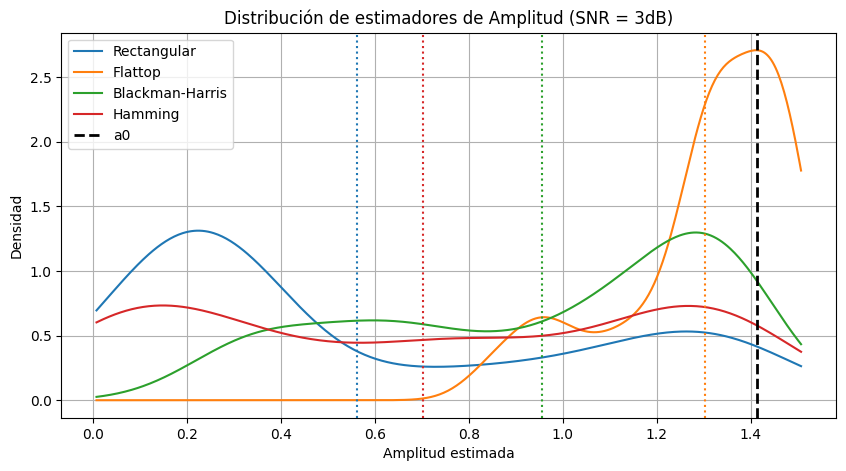

In [20]:
#%% Estimador de Amplitud
a0 = vmax

a_rt = 2 * np.abs(X_rt[:, N//4])
a_ft = 2 * np.abs(X_ft[:, N//4])
a_bm = 2 * np.abs(X_bm[:, N//4])
a_hm = 2 * np.abs(X_hm[:, N//4])

# Sesgos
Sa_rt = np.mean(a_rt) - a0
Sa_ft = np.mean(a_ft) - a0
Sa_bm = np.mean(a_bm) - a0
Sa_hm = np.mean(a_hm) - a0

# Varianza
Va_rt = np.var(a_rt)
Va_ft = np.var(a_ft)
Va_bm = np.var(a_bm)
Va_hm = np.var(a_hm)

print("\nResultados Estimadores de Amplitud:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sa_rt:>15.6e}{Va_rt:>15.6e}")
print(f"{'Flattop':<15}{Sa_ft:>15.6e}{Va_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sa_bm:>15.6e}{Va_bm:>15.6e}")
print(f"{'Hamming':<15}{Sa_hm:>15.6e}{Va_hm:>15.6e}")

#%% Grafico de Densidad de Probabilidad
plt.figure(figsize=(10,5))

# Rango común
xmin = min(a_rt.min(), a_ft.min(), a_bm.min(), a_hm.min())
xmax = max(a_rt.max(), a_ft.max(), a_bm.max(), a_hm.max())
x_vals = np.linspace(xmin, xmax, 500)

# KDE (curvas suaves)
kde_rt = gaussian_kde(a_rt)
kde_ft = gaussian_kde(a_ft)
kde_bm = gaussian_kde(a_bm)
kde_hm = gaussian_kde(a_hm)

plt.plot(x_vals, kde_rt(x_vals), label='Rectangular')
plt.plot(x_vals, kde_ft(x_vals), label='Flattop')
plt.plot(x_vals, kde_bm(x_vals), label='Blackman-Harris')
plt.plot(x_vals, kde_hm(x_vals), label='Hamming')

# Líneas verticales
plt.axvline(a0, color='k', linestyle='--', linewidth=2, label='a0')
plt.axvline(np.mean(a_rt), linestyle=':', color='C0')
plt.axvline(np.mean(a_ft), linestyle=':', color='C1')
plt.axvline(np.mean(a_bm), linestyle=':', color='C2')
plt.axvline(np.mean(a_hm), linestyle=':', color='C3')

plt.xlabel('Amplitud estimada')
plt.ylabel('Densidad')
plt.title(f"Distribución de estimadores de Amplitud (SNR = {SNR}dB)")
plt.legend()
plt.grid()

### Estimador de Frecuencia (SNR = 3dB)


Resultados Estimadores de Frecuencia:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -2.646596e-05   1.016492e-04
Flattop           3.636590e-05   1.126913e-04
Blackman-Harris   4.949971e-06   1.022364e-04
Hamming           4.949971e-06   1.022364e-04


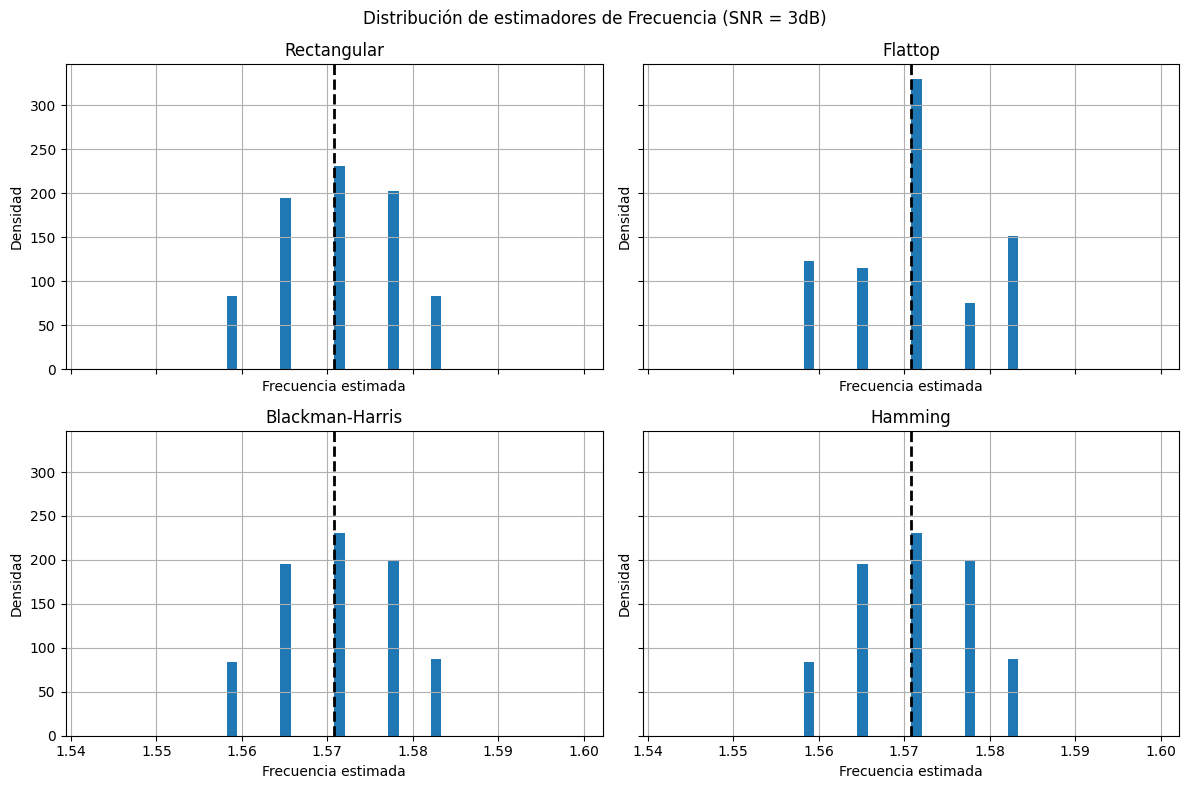

In [21]:
#%% Estimador de Frecuencia
X_rt_u = np.abs(X_rt[:, :N//2])
X_ft_u = np.abs(X_ft[:, :N//2])
X_bm_u = np.abs(X_bm[:, :N//2])
X_hm_u = np.abs(X_hm[:, :N//2])

fmax_rt = np.argmax(np.abs(X_rt_u), axis=1)*deltaf
fmax_ft = np.argmax(np.abs(X_ft_u), axis=1)*deltaf
fmax_bm = np.argmax(np.abs(X_bm_u), axis=1)*deltaf
fmax_hm = np.argmax(np.abs(X_hm_u), axis=1)*deltaf

# Sesgos
Sf_rt = np.mean(fmax_rt - ff)
Sf_ft = np.mean(fmax_ft - ff)
Sf_bm = np.mean(fmax_bm - ff)
Sf_hm = np.mean(fmax_hm - ff)

# Varianza
Vf_rt = np.var(fmax_rt - ff)
Vf_ft = np.var(fmax_ft - ff)
Vf_bm = np.var(fmax_bm - ff)
Vf_hm = np.var(fmax_hm - ff)

print("\nResultados Estimadores de Frecuencia:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sf_rt:>15.6e}{Vf_rt:>15.6e}")
print(f"{'Flattop':<15}{Sf_ft:>15.6e}{Vf_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sf_bm:>15.6e}{Vf_bm:>15.6e}")
print(f"{'Hamming':<15}{Sf_hm:>15.6e}{Vf_hm:>15.6e}")

#%% Grafico de Distribución (Frecuencia) - Subplots

fig, axs = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)

# --- Rectangular ---
axs[0,0].hist(fmax_rt, bins=20, density=True)
axs[0,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,0].set_title('Rectangular')
axs[0,0].grid()

# --- Flattop ---
axs[0,1].hist(fmax_ft, bins=20, density=True)
axs[0,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,1].set_title('Flattop')
axs[0,1].grid()

# --- Blackman-Harris ---
axs[1,0].hist(fmax_bm, bins=20, density=True)
axs[1,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,0].set_title('Blackman-Harris')
axs[1,0].grid()

# --- Hamming ---
axs[1,1].hist(fmax_hm, bins=20, density=True)
axs[1,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,1].set_title('Hamming')
axs[1,1].grid()

for ax in axs.flat:
    ax.set_xlim(fo - 5*deltaf, fo + 5*deltaf)
    ax.set_xlabel('Frecuencia estimada')
    ax.set_ylabel('Densidad')

plt.suptitle(f"Distribución de estimadores de Frecuencia (SNR = {SNR}dB)")
plt.tight_layout()
plt.show()

### Repetimos para SNR = 10db:

In [22]:
vmax = np.sqrt(2)
fo =  np.pi/2 
fr = np.random.uniform(-2,2,200)
ff = fo + fr * deltaf
ff = ff.reshape((M, 1))
SNR = 10

_, x = signal_n(wave='sine', vmax=vmax, dc=0, ff=ff, ph=0, nn=N, fs=fs, snr=SNR)

x_rt = x #Rectangular
x_ft = x * sig.windows.flattop(N)/ np.mean(sig.windows.flattop(N))
x_bm = x * sig.windows.blackmanharris(N)/ np.mean(sig.windows.blackmanharris(N))
x_hm = x * sig.windows.hamming(N)/ np.mean(sig.windows.hamming(N))

X_rt = np.fft.fft(x_rt, axis = 1)/N
X_ft = np.fft.fft(x_ft, axis = 1)/N
X_bm = np.fft.fft(x_bm, axis = 1)/N
X_hm = np.fft.fft(x_hm, axis = 1)/N

f  = np.arange(start = 0, stop = fs, step = deltaf)


### Estimador de Amplitud (SNR = 10dB)


Resultados Estimadores de Amplitud:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -9.504174e-01   1.852338e-01
Flattop          -1.398677e-01   2.168366e-02
Blackman-Harris  -5.424817e-01   1.392598e-01
Hamming          -8.258397e-01   2.443207e-01


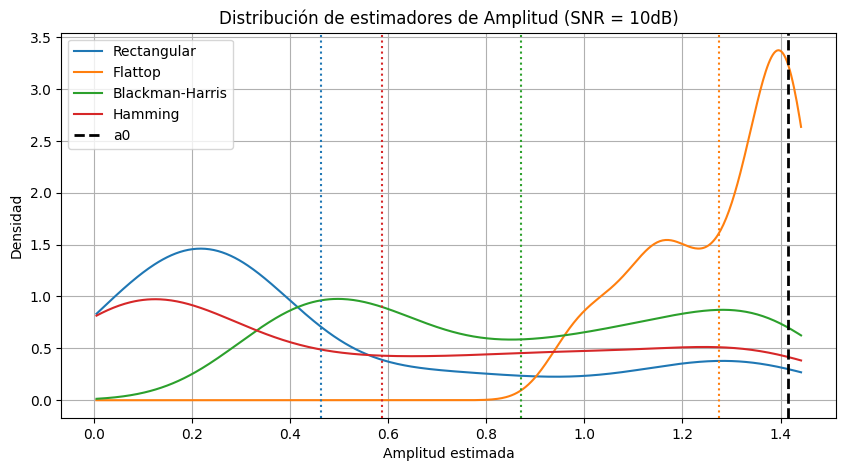

In [23]:
#%% Estimador de Amplitud
a0 = vmax

a_rt = 2 * np.abs(X_rt[:, N//4])
a_ft = 2 * np.abs(X_ft[:, N//4])
a_bm = 2 * np.abs(X_bm[:, N//4])
a_hm = 2 * np.abs(X_hm[:, N//4])

# Sesgos
Sa_rt = np.mean(a_rt) - a0
Sa_ft = np.mean(a_ft) - a0
Sa_bm = np.mean(a_bm) - a0
Sa_hm = np.mean(a_hm) - a0

# Varianza
Va_rt = np.var(a_rt)
Va_ft = np.var(a_ft)
Va_bm = np.var(a_bm)
Va_hm = np.var(a_hm)

print("\nResultados Estimadores de Amplitud:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sa_rt:>15.6e}{Va_rt:>15.6e}")
print(f"{'Flattop':<15}{Sa_ft:>15.6e}{Va_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sa_bm:>15.6e}{Va_bm:>15.6e}")
print(f"{'Hamming':<15}{Sa_hm:>15.6e}{Va_hm:>15.6e}")

#%% Grafico de Densidad de Probabilidad
plt.figure(figsize=(10,5))

# Rango común
xmin = min(a_rt.min(), a_ft.min(), a_bm.min(), a_hm.min())
xmax = max(a_rt.max(), a_ft.max(), a_bm.max(), a_hm.max())
x_vals = np.linspace(xmin, xmax, 500)

# KDE (curvas suaves)
kde_rt = gaussian_kde(a_rt)
kde_ft = gaussian_kde(a_ft)
kde_bm = gaussian_kde(a_bm)
kde_hm = gaussian_kde(a_hm)

plt.plot(x_vals, kde_rt(x_vals), label='Rectangular')
plt.plot(x_vals, kde_ft(x_vals), label='Flattop')
plt.plot(x_vals, kde_bm(x_vals), label='Blackman-Harris')
plt.plot(x_vals, kde_hm(x_vals), label='Hamming')

# Líneas verticales
plt.axvline(a0, color='k', linestyle='--', linewidth=2, label='a0')
plt.axvline(np.mean(a_rt), linestyle=':', color='C0')
plt.axvline(np.mean(a_ft), linestyle=':', color='C1')
plt.axvline(np.mean(a_bm), linestyle=':', color='C2')
plt.axvline(np.mean(a_hm), linestyle=':', color='C3')

plt.xlabel('Amplitud estimada')
plt.ylabel('Densidad')
plt.title(f"Distribución de estimadores de Amplitud (SNR = {SNR}dB)")
plt.legend()
plt.grid()

### Estimador de Frecuencia (SNR = 10dB)


Resultados Estimadores de Frecuencia:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -4.146651e-05   1.302381e-04
Flattop          -4.146651e-05   1.266851e-04
Blackman-Harris  -1.042984e-04   1.303132e-04
Hamming          -7.288243e-05   1.304740e-04


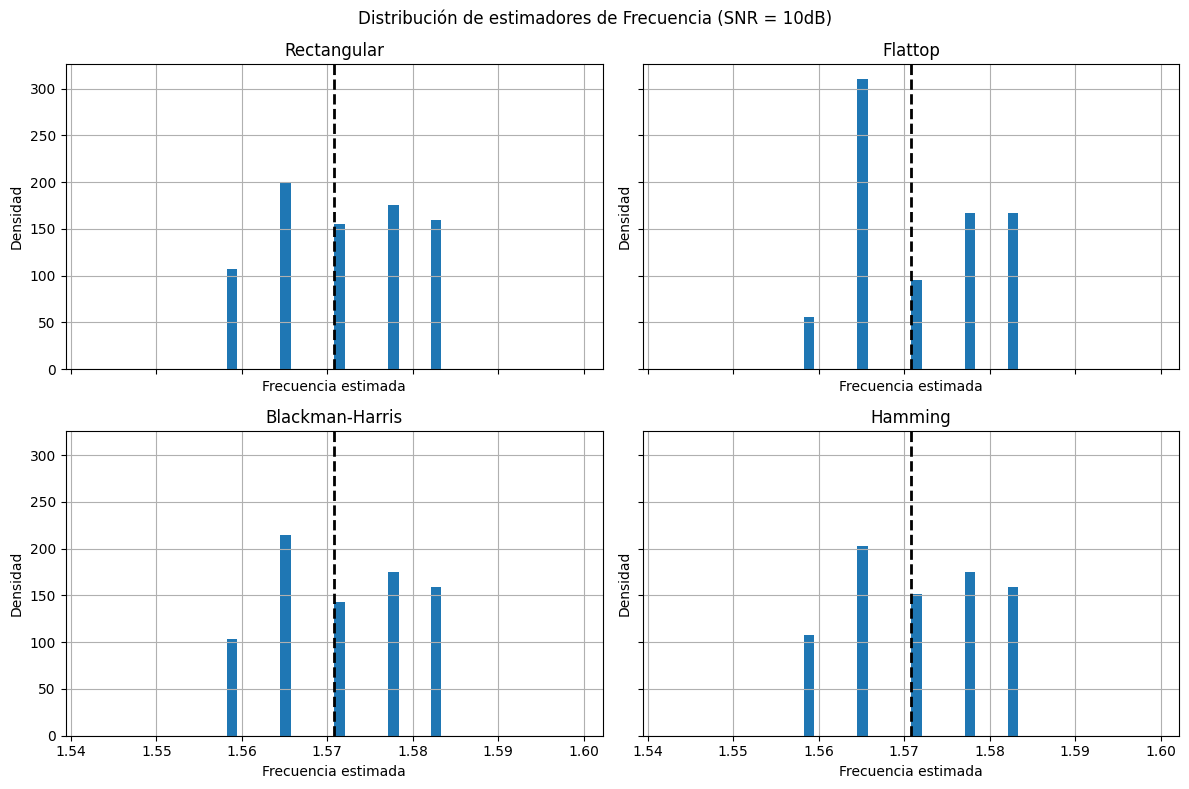

In [24]:
#%% Estimador de Frecuencia
X_rt_u = np.abs(X_rt[:, :N//2])
X_ft_u = np.abs(X_ft[:, :N//2])
X_bm_u = np.abs(X_bm[:, :N//2])
X_hm_u = np.abs(X_hm[:, :N//2])

fmax_rt = np.argmax(np.abs(X_rt_u), axis=1)*deltaf
fmax_ft = np.argmax(np.abs(X_ft_u), axis=1)*deltaf
fmax_bm = np.argmax(np.abs(X_bm_u), axis=1)*deltaf
fmax_hm = np.argmax(np.abs(X_hm_u), axis=1)*deltaf

# Sesgos
Sf_rt = np.mean(fmax_rt - ff)
Sf_ft = np.mean(fmax_ft - ff)
Sf_bm = np.mean(fmax_bm - ff)
Sf_hm = np.mean(fmax_hm - ff)

# Varianza
Vf_rt = np.var(fmax_rt - ff)
Vf_ft = np.var(fmax_ft - ff)
Vf_bm = np.var(fmax_bm - ff)
Vf_hm = np.var(fmax_hm - ff)

print("\nResultados Estimadores de Frecuencia:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sf_rt:>15.6e}{Vf_rt:>15.6e}")
print(f"{'Flattop':<15}{Sf_ft:>15.6e}{Vf_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sf_bm:>15.6e}{Vf_bm:>15.6e}")
print(f"{'Hamming':<15}{Sf_hm:>15.6e}{Vf_hm:>15.6e}")

#%% Grafico de Distribución (Frecuencia) - Subplots

fig, axs = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)

# --- Rectangular ---
axs[0,0].hist(fmax_rt, bins=20, density=True)
axs[0,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,0].set_title('Rectangular')
axs[0,0].grid()

# --- Flattop ---
axs[0,1].hist(fmax_ft, bins=20, density=True)
axs[0,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,1].set_title('Flattop')
axs[0,1].grid()

# --- Blackman-Harris ---
axs[1,0].hist(fmax_bm, bins=20, density=True)
axs[1,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,0].set_title('Blackman-Harris')
axs[1,0].grid()

# --- Hamming ---
axs[1,1].hist(fmax_hm, bins=20, density=True)
axs[1,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,1].set_title('Hamming')
axs[1,1].grid()

for ax in axs.flat:
    ax.set_xlim(fo - 5*deltaf, fo + 5*deltaf)
    ax.set_xlabel('Frecuencia estimada')
    ax.set_ylabel('Densidad')

plt.suptitle(f"Distribución de estimadores de Frecuencia (SNR = {SNR}dB)")
plt.tight_layout()
plt.show()

## Bonus: Zero Padding (SNR = 10dB).

In [25]:
vmax = np.sqrt(2)
fo =  np.pi/2 
fr = np.random.uniform(-2,2,200)
ff = fo + fr * deltaf
ff = ff.reshape((M, 1))
SNR = 10

_, x = signal_n(wave='sine', vmax=vmax, dc=0, ff=ff, ph=0, nn=N, fs=fs, snr=SNR)

x_rt = x #Rectangular
x_ft = x * sig.windows.flattop(N)/ np.mean(sig.windows.flattop(N))
x_bm = x * sig.windows.blackmanharris(N)/ np.mean(sig.windows.blackmanharris(N))
x_hm = x * sig.windows.hamming(N)/ np.mean(sig.windows.hamming(N))

#%% Zero Padding
Np = 9*N
Nt = N + Np

xz_rt = np.pad(x_rt, ((0,0),(0,Np)), mode='constant')
xz_ft = np.pad(x_ft, ((0,0),(0,Np)), mode='constant')
xz_bm = np.pad(x_bm, ((0,0),(0,Np)), mode='constant')
xz_hm = np.pad(x_hm, ((0,0),(0,Np)), mode='constant')

#%% FFT
X_rt = np.fft.fft(xz_rt, axis = 1)/N
X_ft = np.fft.fft(xz_ft, axis = 1)/N
X_bm = np.fft.fft(xz_bm, axis = 1)/N
X_hm = np.fft.fft(xz_hm, axis = 1)/N

f  = np.arange(start = 0, stop = fs, step = deltaf)

### Estimador de Amplitud (SNR = 10dB y Zero Padding)


Resultados Estimadores de Amplitud:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -9.117428e-01   1.922099e-01
Flattop          -1.105144e-01   1.741489e-02
Blackman-Harris  -4.717058e-01   1.241036e-01
Hamming          -7.409829e-01   2.285751e-01


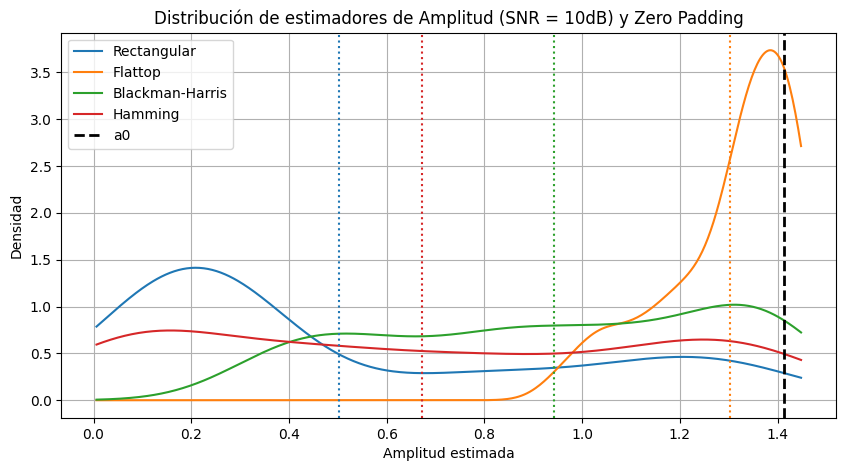

In [26]:
#%% Estimador de Amplitud
a0 = vmax

a_rt = 2 * np.abs(X_rt[:, Nt//4])
a_ft = 2 * np.abs(X_ft[:, Nt//4])
a_bm = 2 * np.abs(X_bm[:, Nt//4])
a_hm = 2 * np.abs(X_hm[:, Nt//4])

# Sesgos
Sa_rt = np.mean(a_rt) - a0
Sa_ft = np.mean(a_ft) - a0
Sa_bm = np.mean(a_bm) - a0
Sa_hm = np.mean(a_hm) - a0

# Varianza
Va_rt = np.var(a_rt)
Va_ft = np.var(a_ft)
Va_bm = np.var(a_bm)
Va_hm = np.var(a_hm)

print("\nResultados Estimadores de Amplitud:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sa_rt:>15.6e}{Va_rt:>15.6e}")
print(f"{'Flattop':<15}{Sa_ft:>15.6e}{Va_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sa_bm:>15.6e}{Va_bm:>15.6e}")
print(f"{'Hamming':<15}{Sa_hm:>15.6e}{Va_hm:>15.6e}")

#%% Grafico de Densidad de Probabilidad
plt.figure(figsize=(10,5))

# Rango común
xmin = min(a_rt.min(), a_ft.min(), a_bm.min(), a_hm.min())
xmax = max(a_rt.max(), a_ft.max(), a_bm.max(), a_hm.max())
x_vals = np.linspace(xmin, xmax, 500)

# KDE (curvas suaves)
kde_rt = gaussian_kde(a_rt)
kde_ft = gaussian_kde(a_ft)
kde_bm = gaussian_kde(a_bm)
kde_hm = gaussian_kde(a_hm)

plt.plot(x_vals, kde_rt(x_vals), label='Rectangular')
plt.plot(x_vals, kde_ft(x_vals), label='Flattop')
plt.plot(x_vals, kde_bm(x_vals), label='Blackman-Harris')
plt.plot(x_vals, kde_hm(x_vals), label='Hamming')

# Líneas verticales
plt.axvline(a0, color='k', linestyle='--', linewidth=2, label='a0')
plt.axvline(np.mean(a_rt), linestyle=':', color='C0')
plt.axvline(np.mean(a_ft), linestyle=':', color='C1')
plt.axvline(np.mean(a_bm), linestyle=':', color='C2')
plt.axvline(np.mean(a_hm), linestyle=':', color='C3')

plt.xlabel('Amplitud estimada')
plt.ylabel('Densidad')
plt.title(f"Distribución de estimadores de Amplitud (SNR = {SNR}dB) y Zero Padding")
plt.legend()
plt.grid()

### Estimador de Frecuencia (SNR = 10dB y Zero Padding)


Resultados Estimadores de Frecuencia:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -2.795881e-06   9.811817e-05
Flattop           4.056112e-04   1.057251e-04
Blackman-Harris   6.628897e-06   9.792862e-05
Hamming           3.487304e-06   9.790629e-05


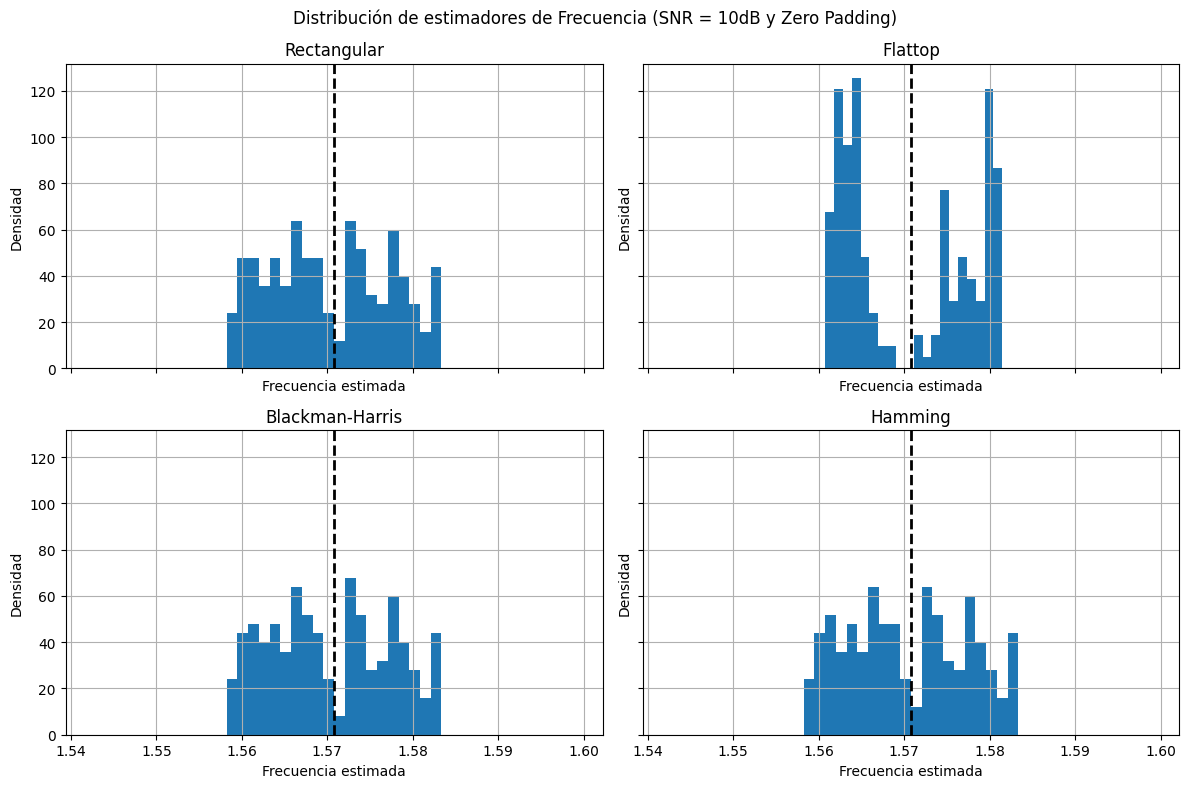

In [27]:
#%% Estimador de Frecuencia
X_rt_u = np.abs(X_rt[:, :Nt//2])
X_ft_u = np.abs(X_ft[:, :Nt//2])
X_bm_u = np.abs(X_bm[:, :Nt//2])
X_hm_u = np.abs(X_hm[:, :Nt//2])

deltafn = fs/Nt

fmax_rt = np.argmax(np.abs(X_rt_u), axis=1)*deltafn
fmax_ft = np.argmax(np.abs(X_ft_u), axis=1)*deltafn
fmax_bm = np.argmax(np.abs(X_bm_u), axis=1)*deltafn
fmax_hm = np.argmax(np.abs(X_hm_u), axis=1)*deltafn

# Sesgos
Sf_rt = np.mean(fmax_rt - ff)
Sf_ft = np.mean(fmax_ft - ff)
Sf_bm = np.mean(fmax_bm - ff)
Sf_hm = np.mean(fmax_hm - ff)

# Varianza
Vf_rt = np.var(fmax_rt - ff)
Vf_ft = np.var(fmax_ft - ff)
Vf_bm = np.var(fmax_bm - ff)
Vf_hm = np.var(fmax_hm - ff)

print("\nResultados Estimadores de Frecuencia:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sf_rt:>15.6e}{Vf_rt:>15.6e}")
print(f"{'Flattop':<15}{Sf_ft:>15.6e}{Vf_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sf_bm:>15.6e}{Vf_bm:>15.6e}")
print(f"{'Hamming':<15}{Sf_hm:>15.6e}{Vf_hm:>15.6e}")

#%% Grafico de Distribución (Frecuencia) - Subplots

fig, axs = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)

# --- Rectangular ---
axs[0,0].hist(fmax_rt, bins=20, density=True)
axs[0,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,0].set_title('Rectangular')
axs[0,0].grid()

# --- Flattop ---
axs[0,1].hist(fmax_ft, bins=20, density=True)
axs[0,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,1].set_title('Flattop')
axs[0,1].grid()

# --- Blackman-Harris ---
axs[1,0].hist(fmax_bm, bins=20, density=True)
axs[1,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,0].set_title('Blackman-Harris')
axs[1,0].grid()

# --- Hamming ---
axs[1,1].hist(fmax_hm, bins=20, density=True)
axs[1,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,1].set_title('Hamming')
axs[1,1].grid()

for ax in axs.flat:
    ax.set_xlim(fo - 5*deltaf, fo + 5*deltaf)
    ax.set_xlabel('Frecuencia estimada')
    ax.set_ylabel('Densidad')

plt.suptitle(f"Distribución de estimadores de Frecuencia (SNR = {SNR}dB y Zero Padding)")
plt.tight_layout()
plt.show()

Como podemos observar, al contar con una mayor resolución espectral, existen valoresde frecuencias posibles más cercanas a la real. En consecuencia, notamos que el valor del sesgo es de un orden de magnitud con respecto al caso sin Zero padding.

## Bonus: Estimadores Alternativos.
### Estimador de Amplitud (SNR = 10dB)
Para estimar la amplitud decidimos realizar una suma de las energias en un entorno de fo. Para este ancho de banda se decide utilizar el de 4*deltaf del ruido de frecuencia uniforme aplicado en nuestro modelo de señal:


Resultados Estimadores de Amplitud:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular      -3.274705e-02   8.732333e-04
Flattop           1.114575e+00   2.930214e-02
Blackman-Harris   5.316595e-01   6.184881e-03
Hamming           2.269133e-01   1.055277e-03


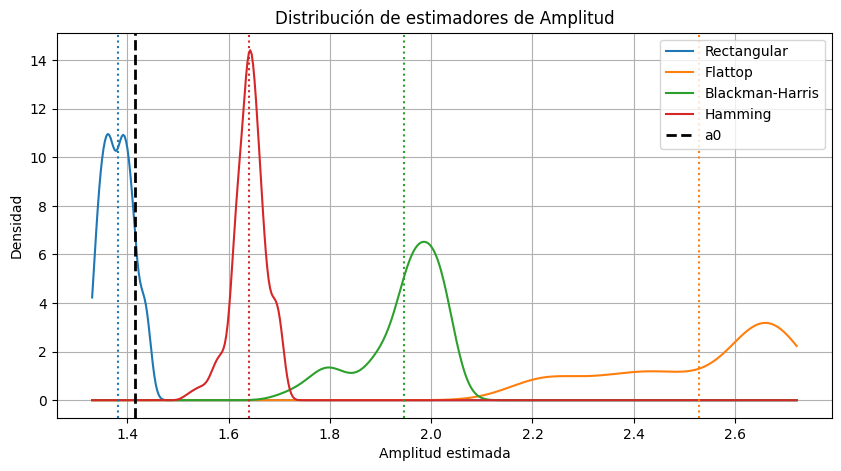

In [28]:
vmax = np.sqrt(2)
fo =  np.pi/2 
fr = np.random.uniform(-2,2,200)
ff = fo + fr * deltaf
ff = ff.reshape((M, 1))
SNR = 10

_, x = signal_n(wave='sine', vmax=vmax, dc=0, ff=ff, ph=0, nn=N, fs=fs, snr=SNR)

x_rt = x #Rectangular
x_ft = x * sig.windows.flattop(N)/ np.mean(sig.windows.flattop(N))
x_bm = x * sig.windows.blackmanharris(N)/ np.mean(sig.windows.blackmanharris(N))
x_hm = x * sig.windows.hamming(N)/ np.mean(sig.windows.hamming(N))

X_rt = np.fft.fft(x_rt, axis = 1)/N
X_ft = np.fft.fft(x_ft, axis = 1)/N
X_bm = np.fft.fft(x_bm, axis = 1)/N
X_hm = np.fft.fft(x_hm, axis = 1)/N

f  = np.arange(start = 0, stop = fs, step = deltaf)

#%% Estimador de Amplitud
a0 = vmax

a_rt = 2 * np.sqrt(np.sum(np.abs(X_rt[:, N//4 - 2 : N//4 + 2 + 1])**2, axis=1))
a_ft = 2 * np.sqrt(np.sum(np.abs(X_ft[:, N//4 - 2 : N//4 + 2 + 1])**2, axis=1))
a_bm = 2 * np.sqrt(np.sum(np.abs(X_bm[:, N//4 - 2 : N//4 + 2 + 1])**2, axis=1))
a_hm = 2 * np.sqrt(np.sum(np.abs(X_hm[:, N//4 - 2 : N//4 + 2 + 1])**2, axis=1))

# Sesgos
Sa_rt = np.mean(a_rt) - a0
Sa_ft = np.mean(a_ft) - a0
Sa_bm = np.mean(a_bm) - a0
Sa_hm = np.mean(a_hm) - a0

# Varianza
Va_rt = np.var(a_rt)
Va_ft = np.var(a_ft)
Va_bm = np.var(a_bm)
Va_hm = np.var(a_hm)

print("\nResultados Estimadores de Amplitud:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sa_rt:>15.6e}{Va_rt:>15.6e}")
print(f"{'Flattop':<15}{Sa_ft:>15.6e}{Va_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sa_bm:>15.6e}{Va_bm:>15.6e}")
print(f"{'Hamming':<15}{Sa_hm:>15.6e}{Va_hm:>15.6e}")

#%% Grafico de Densidad de Probabilidad
plt.figure(figsize=(10,5))

# Rango común
xmin = min(a_rt.min(), a_ft.min(), a_bm.min(), a_hm.min())
xmax = max(a_rt.max(), a_ft.max(), a_bm.max(), a_hm.max())
x_vals = np.linspace(xmin, xmax, 500)

# KDE (curvas suaves)
kde_rt = gaussian_kde(a_rt)
kde_ft = gaussian_kde(a_ft)
kde_bm = gaussian_kde(a_bm)
kde_hm = gaussian_kde(a_hm)

plt.plot(x_vals, kde_rt(x_vals), label='Rectangular')
plt.plot(x_vals, kde_ft(x_vals), label='Flattop')
plt.plot(x_vals, kde_bm(x_vals), label='Blackman-Harris')
plt.plot(x_vals, kde_hm(x_vals), label='Hamming')

# Líneas verticales
plt.axvline(a0, color='k', linestyle='--', linewidth=2, label='a0')
plt.axvline(np.mean(a_rt), linestyle=':', color='C0')
plt.axvline(np.mean(a_ft), linestyle=':', color='C1')
plt.axvline(np.mean(a_bm), linestyle=':', color='C2')
plt.axvline(np.mean(a_hm), linestyle=':', color='C3')

plt.xlabel('Amplitud estimada')
plt.ylabel('Densidad')
plt.title('Distribución de estimadores de Amplitud')
plt.legend()
plt.grid()

Podemos observar que este estimador realiza una estimacion por exceso para la mayoria de ventanas. Al mismo tiempo, notamos que logramos reducir en todos los casos la varianza un orden de magnitud.
### Estimador de Frecuencia (SNR = 10dB)
Para el estimador de frecuencia vamos a ponderar la frecuencia por la energia en ese valor de N ("Centro de masa"). Analizando siempre en un entorno de 4 deltaf:


Resultados Estimadores de Frecuencia:

Ventana                  Sesgo       Varianza
---------------------------------------------
Rectangular       9.278957e-05   8.479243e-05
Flattop           6.501701e-06   6.725271e-05
Blackman-Harris  -5.576644e-06   8.455044e-05
Hamming           1.746140e-05   9.609277e-05


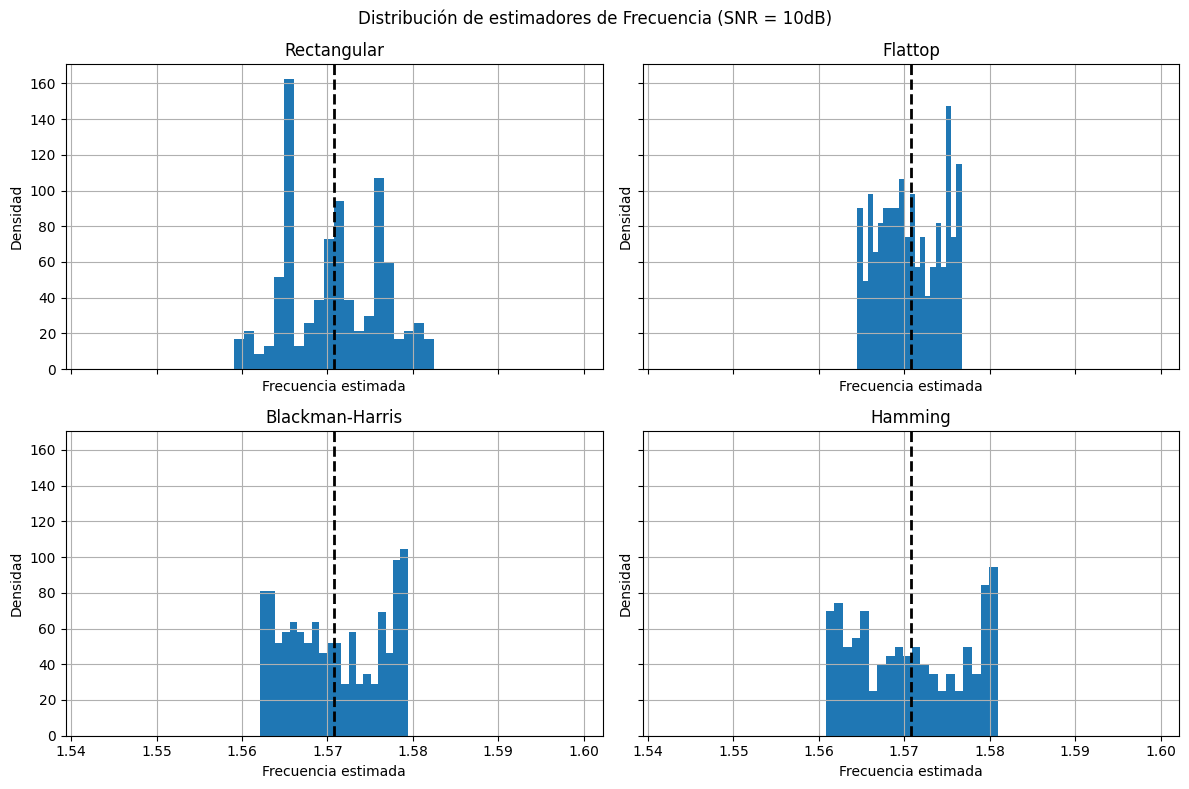

In [29]:
#%% Estimador de Frecuencia
X_rt_u = np.abs(X_rt[:, :N//2])
X_ft_u = np.abs(X_ft[:, :N//2])
X_bm_u = np.abs(X_bm[:, :N//2])
X_hm_u = np.abs(X_hm[:, :N//2])
 
idx = slice(N//4 - 2, N//4 + 3)
f_sel = f[idx]

fmax_rt = np.sum(f_sel * np.abs(X_rt[:, idx]), axis=1) / np.sum(np.abs(X_rt[:, idx]), axis=1)
fmax_ft = np.sum(f_sel * np.abs(X_ft[:, idx]), axis=1) / np.sum(np.abs(X_ft[:, idx]), axis=1)
fmax_bm = np.sum(f_sel * np.abs(X_bm[:, idx]), axis=1) / np.sum(np.abs(X_bm[:, idx]), axis=1)
fmax_hm = np.sum(f_sel * np.abs(X_hm[:, idx]), axis=1) / np.sum(np.abs(X_hm[:, idx]), axis=1)

# Sesgos
Sf_rt = np.mean(fmax_rt - ff)
Sf_ft = np.mean(fmax_ft - ff)
Sf_bm = np.mean(fmax_bm - ff)
Sf_hm = np.mean(fmax_hm - ff)

# Varianza
Vf_rt = np.var(fmax_rt - ff)
Vf_ft = np.var(fmax_ft - ff)
Vf_bm = np.var(fmax_bm - ff)
Vf_hm = np.var(fmax_hm - ff)

print("\nResultados Estimadores de Frecuencia:\n")
print(f"{'Ventana':<15}{'Sesgo':>15}{'Varianza':>15}")
print("-"*45)
print(f"{'Rectangular':<15}{Sf_rt:>15.6e}{Vf_rt:>15.6e}")
print(f"{'Flattop':<15}{Sf_ft:>15.6e}{Vf_ft:>15.6e}")
print(f"{'Blackman-Harris':<15}{Sf_bm:>15.6e}{Vf_bm:>15.6e}")
print(f"{'Hamming':<15}{Sf_hm:>15.6e}{Vf_hm:>15.6e}")

#%% Grafico de Distribución (Frecuencia) - Subplots

fig, axs = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)

# --- Rectangular ---
axs[0,0].hist(fmax_rt, bins=20, density=True)
axs[0,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,0].set_title('Rectangular')
axs[0,0].grid()

# --- Flattop ---
axs[0,1].hist(fmax_ft, bins=20, density=True)
axs[0,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[0,1].set_title('Flattop')
axs[0,1].grid()

# --- Blackman-Harris ---
axs[1,0].hist(fmax_bm, bins=20, density=True)
axs[1,0].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,0].set_title('Blackman-Harris')
axs[1,0].grid()

# --- Hamming ---
axs[1,1].hist(fmax_hm, bins=20, density=True)
axs[1,1].axvline(fo, color='k', linestyle='--', linewidth=2)
axs[1,1].set_title('Hamming')
axs[1,1].grid()

for ax in axs.flat:
    ax.set_xlim(fo - 5*deltaf, fo + 5*deltaf)
    ax.set_xlabel('Frecuencia estimada')
    ax.set_ylabel('Densidad')

plt.suptitle(f"Distribución de estimadores de Frecuencia (SNR = {SNR}dB)")
plt.tight_layout()
plt.show()

Nuevamente notamos una clara mejora en la varianza de nuestro estimador, reduciendose esta un orden de magnitud.